# Visualising Sentinel-2 Data with Python

Sentinel-2 data are delivered as `.SAFE` folders, which contain satellite imagery and metadata for a specific sensing event. These data are divided **tiles** representing fixed spatial areas on Earth's surface, each measuring approximately **100 km x 100 km**.

In this tutorial, you'll learn how to:

- Load Sentinel-2 Level-2A `.SAFE` data locally
- Extract and plot the data for an individual band
- Extract and plot a true colour image of the data by stacking together the RGB bands (B04, B03, B02)

Let's get started!

In [1]:
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt

## Naming Convention

Each `.SAFE` folder has a structured name with embedded metadata, using the following general format:

```
S2[A/B/C]_MSIL2A_YYYYMMDDTHHMMSS_Nxxxx_Rxxx_TXXXXX_YYYYMMDDTHHMMSS.SAFE
```

| Component        | Meaning                                            |
|------------------|----------------------------------------------------|
| `S2A` / `S2B` / `S2C` | Satellite platform (Sentinel-2A, B, or C)             |
| `MSIL2A`          | Processing level (L2A = surface reflectance)      |
| `YYYYMMDDTHHMMSS` | Sensing date and time (UTC)                       |
| `Nxxxx`           | Processing baseline version                        |
| `Rxxx`            | Relative orbit number                              |
| `TXXXXX`          | **Tile ID**, e.g. `T32VPN`                         |
| `YYYYMMDDTHHMMSS` | Product generation time                            |

The **Tile ID** (e.g. `T32VPN`) corresponds to the **Military Grid Reference System (MGRS)**, and refers to a specific geographic region. This ID appears consistently in filenames and paths throughout the product.

## Understanding the Sentinel-2 `.SAFE` folder structure

The `.SAFE` folder has a nested directory structure. Each tile (granule) is stored under the `GRANULE/` subdirectory, and contains image files at different resolutions in `IMG_DATA/`.

A generalised path to a 10 m band image looks like:

```
<PRODUCT>.SAFE/GRANULE/L2A_<TILE_ID>_<SENSING_TIME>/IMG_DATA/R10m/<TILE_ID>_<SENSING_TIME>_<BAND>_10m.jp2
```

### Example structure:

```
S2B_MSIL2A_20250708T104629_N0511_R051_T32VPN_20250708T132039.SAFE/
├── GRANULE/
│   └── L2A_T32VPN_20250708T104854/
│       └── IMG_DATA/
│           ├── R10m/
│           │   ├── T32VPN_20250708T104629_B02_10m.jp2
│           │   └── T32VPN_20250708T104629_SCL_10m.jp2
│           ├── R20m/
│           └── R60m/
```

- `R10m`, `R20m`, `R60m`: Folders containing images at 10 m, 20 m, and 60 m resolutions respectively.
- Image files follow the pattern: `<TILE_ID>_<SENSING_TIME>_<LAYER>_<RES>.jp2`


## Image and Auxiliary Data Layers

The table below summarises all bands and auxiliary layers provided in L2A products:

| Layer | Name                 | Description                              | Central Wavelength (nm) |
|-------|----------------------|------------------------------------------|--------------------------|
| B01   | Coastal aerosol      | Aerosol scattering                        | 443                      |
| B02   | Blue                 | Visible blue light                        | 490                      |
| B03   | Green                | Visible green light                       | 560                      |
| B04   | Red                  | Visible red light                         | 665                      |
| B05   | Vegetation red edge  | Red edge for vegetation analysis          | 705                      |
| B06   | Vegetation red edge  | Red edge for vegetation analysis          | 740                      |
| B07   | Vegetation red edge  | Red edge for vegetation analysis          | 783                      |
| B08   | NIR                  | Near-infrared (vegetation, biomass)       | 842                      |
| B08A  | Narrow NIR           | Narrow band NIR                           | 865                      |
| B09   | Water vapour         | Water vapour absorption                   | 945                      |
| B10   | SWIR - Cirrus        | Cirrus cloud detection                    | 1375                     |
| B11   | SWIR                 | Shortwave infrared                        | 1610                     |
| B12   | SWIR                 | Shortwave infrared                        | 2190                     |
| AOT   | Aerosol Optical Thickness | Aerosol concentration over land     | N/A                      |
| SCL   | Scene Classification | Classification of land cover and clouds  | N/A                      |
| WVP   | Water Vapour         | Total column water vapour                 | N/A                      |
| TCI   | True Colour Image    | RGB composite (from B04, B03, B02)        | N/A                      |

> *Note:* “N/A” in wavelength indicates layers are derived, not based on a single spectral band.

## Tips for New Users

- **Start with TCI or RGB (B04, B03, B02)** for quick visual checks.
- **Use SCL** (Scene Classification) to filter clouds, shadows, and invalid pixels.
- **Combine bands** for vegetation indices (e.g. NDVI = (B08 - B04)/(B08 + B04)).
- **All images are georeferenced JP2 files**, suitable for use in QGIS, Python (e.g. with `rasterio`), or other GIS tools.
  
Our goal:
- Find the granule folder
- Locate the 10m resolution images inside the `IMG_DATA` folder (sometimes in a subfolder called `R10m`)
- Identify the RGB bands:
    - Band 4 (B04) – Red
    - Band 3 (B03) – Green
    - Band 2 (B02) – Blue

In [2]:
# MAKE THIS SCRIPT MORE GENERIC TO TAKE RESOLUTION AS AN ARGUMENT. INCLUDE WITHIN THE FUNCTION AS ARG. MAKE MORE USER FRIENDLY.
# REMOVE THE OUT GOAL BIT OR MOVE IT LATER

# Replace this path with your own Sentinel-2 .SAFE folder location
safe_path = 'data/S2B_MSIL2A_20250708T104629_N0511_R051_T32VPN_20250708T132039.SAFE'

# Locate the granule folder (usually just one granule per SAFE)
granule_dir = os.path.join(safe_path, 'GRANULE')
granule_subdir = next(os.walk(granule_dir))[1][0]

# Locate the IMG_DATA folder inside the granule
img_data_dir = os.path.join(granule_dir, granule_subdir, 'IMG_DATA')

# Some products store the 10m bands in an R10m subfolder
possible_dirs = [os.path.join(img_data_dir, 'R10m'), img_data_dir]
for d in possible_dirs:
    if os.path.exists(d):
        img_path = d
        break
else:
    raise FileNotFoundError("Could not find the 10m resolution image folder")

## Finding bands/layers automatically


In [3]:
def find_band(directory, pattern):
    files = glob.glob(os.path.join(directory, f'*_{pattern}_10m.jp2'))
    if not files:
        raise FileNotFoundError(f"Band {pattern} not found in {directory}")
    return files[0]

def load_band(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32), src.transform

## Loading the RGB bands

Using our helper functions, we can load the three bands into numpy arrays. 

Sentinel-2 reflectance data is stored as scaled integers, so we'll convert them to floats and scale by 10,000 to get values between 0 and 1.

In [4]:
# Find band file paths
band_files = {
    'red': find_band(img_path, 'B04'),
    'green': find_band(img_path, 'B03'),
    'blue': find_band(img_path, 'B02')
}

# Load the bands
red, transform = load_band(band_files['red'])
green, _ = load_band(band_files['green'])
blue, _ = load_band(band_files['blue'])

# Stack the red, green, and blue bands along the last axis to form a 3D RGB image
# Shape becomes (height, width, 3)
rgb = np.dstack((red, green, blue)).astype(np.float32) / 10000.0

# Scale the digital number values to reflectance by dividing by 10000.0
# (Sentinel-2 Level-2A data is typically scaled this way)

# Clip reflectance values to a maximum of 0.3
# This is a form of contrast stretching: it suppresses overly bright areas (e.g. clouds)
# and enhances darker land surfaces (e.g. vegetation, soil, water)
rgb_clipped = np.clip(rgb, 0.0, 0.3)

# Re-normalise the clipped image to the range [0.0, 1.0] for correct display in matplotlib
# This means 0.3 (the max clipped reflectance) becomes pure white (1.0),
# and anything at or below 0.0 remains black (0.0)
rgb_normalised = rgb_clipped / 0.3

## Plotting the True Colour image

Finally, we display the stretched RGB image using Matplotlib.

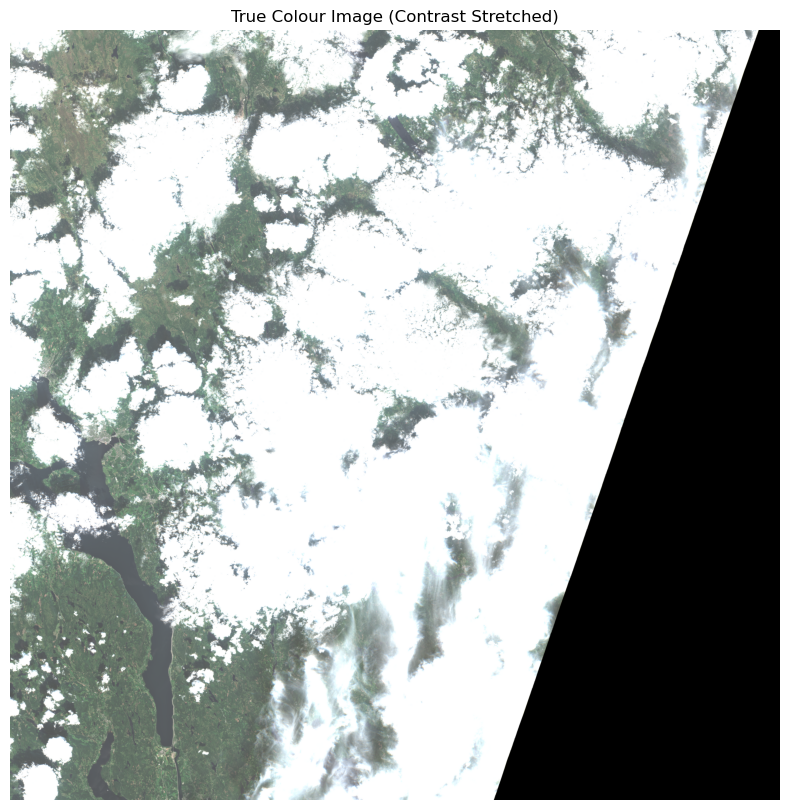

In [5]:
plt.figure(figsize=(10, 10))
plt.imshow(rgb_normalised)
plt.axis('off')
plt.title("True Colour Image (Contrast Stretched)")
plt.show()

We can add some features to improve appearence.

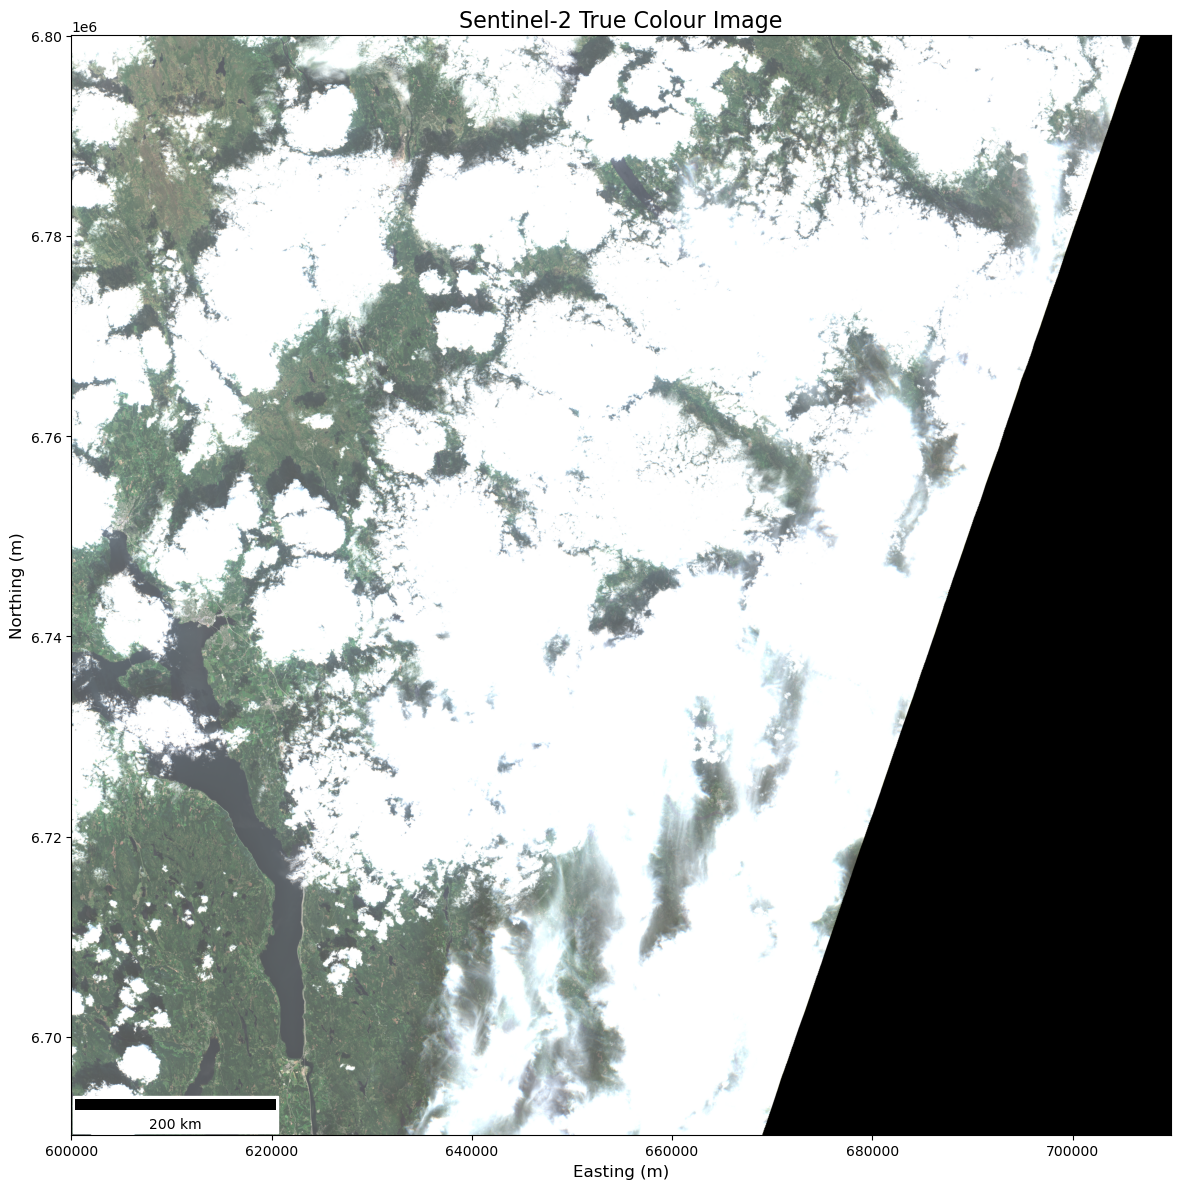

In [8]:
import matplotlib.pyplot as plt
from rasterio.plot import show
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar

# Create the plot with a white background and larger figure
fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')

# Plot the RGB image with the geotransform
show(rgb_normalised.transpose(2, 0, 1), transform=transform, ax=ax)

# Title and axis labels
ax.set_title("Sentinel-2 True Colour Image", fontsize=16)
ax.set_xlabel("Easting (m)", fontsize=12)
ax.set_ylabel("Northing (m)", fontsize=12)

# Add a scale bar (uses pixel size from transform)
scalebar = ScaleBar(transform.a, units="m", location='lower left')
ax.add_artist(scalebar)

# Tidy up the layout
ax.grid(False)
plt.tight_layout()
plt.show()

## Geographic Cropping of Sentinel-2 Imagery

Instead of working with the entire 10 000×10 000 px tile, we can zoom in on any latitude/longitude rectangle.  

**Steps**:  
1. Open each band with `rasterio` (so we get its CRS and transform).  
2. Transform our WGS84 bounding box into the image’s CRS.  
3. Compute a pixel‐window from that box.  
4. Read only that window from each band.  
5. Stack, stretch and plot.

In [9]:
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

def crop_band_to_bbox(band_path, lat_min, lat_max, lon_min, lon_max):
    """
    Open a single-band file and crop it to the given lat/lon box.

    Returns:
      data: 2D np.array of cropped pixels
      transform: new Affine transform for the cropped window
    """
    with rasterio.open(band_path) as src:
        # 1. Transform WGS84 bbox to the band CRS:
        bbox_crs = transform_bounds(
            'EPSG:4326', 
            src.crs, 
            lon_min, lat_min, 
            lon_max, lat_max, 
            densify_pts=21
        )
        # 2. Compute the pixel window:
        window = from_bounds(*bbox_crs, transform=src.transform)
        # 3. Read that window:
        data = src.read(1, window=window).astype(np.float32)
        # 4. Compute the new transform
        new_transform = src.window_transform(window)
    return data, new_transform

Now we’ll:
- Define our lat/lon box  
- Crop each of the red, green and blue bands  
- Stack into an RGB array
- Plot!

In [11]:
# 1. Your bounding box in WGS84:
lat_min, lat_max = 60.46, 60.51    # change to your own
lon_min, lon_max = 11.12, 11.19

# 2. Crop each band:
red_crop, _   = crop_band_to_bbox(band_files['red'],   lat_min, lat_max, lon_min, lon_max)
green_crop, _ = crop_band_to_bbox(band_files['green'], lat_min, lat_max, lon_min, lon_max)
blue_crop, _  = crop_band_to_bbox(band_files['blue'],  lat_min, lat_max, lon_min, lon_max)

# 3. Stack and convert to reflectance:
rgb_crop = np.dstack((red_crop, green_crop, blue_crop)).astype(np.float32) / 10000.0
rgb_crop_clipped = np.clip(rgb_crop, 0.0, 0.3)
rgb_crop_normalised = rgb_crop_clipped / 0.3

# 4. Plot:
plt.figure(figsize=(8, 8))
plt.imshow(rgb_crop_normalised)
plt.axis('off')
plt.title("Cropped Sentinel-2 True Colour")
plt.show()

CRSError: The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/lukem/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.